In [2]:
import numpy as np
import pandas as pd
import matplotlib #
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn #
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import KFold
import mlflow

In [0]:
!pip install mlflow==1.20.2

You should consider upgrading via the '/databricks/python3/bin/python -m pip install --upgrade pip' command.


In [3]:
# # File location and type
# file_location = "/FileStore/tables/creditcard.csv"
# file_type = "csv"

# # CSV options
# infer_schema = "true"
# first_row_is_header = "true"
# delimiter = ","

# # The applied options are for CSV files. For other file types, these will be ignored.
# dataframe = spark.read.format(file_type) \
#   .option("inferSchema", infer_schema) \
#   .option("header", first_row_is_header) \
#   .option("sep", delimiter) \
#   .load(file_location)

# df=dataframe.toPandas()

# Load the data using pandas instead of Spark
file_location = "data/creditcard.csv" 
df = pd.read_csv(file_location)

In [4]:
df = df.drop("Time", axis=1) # cette colonne n'apporte rien à notre analyse 
df.head()
  

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: xlabel='Class', ylabel='count'>

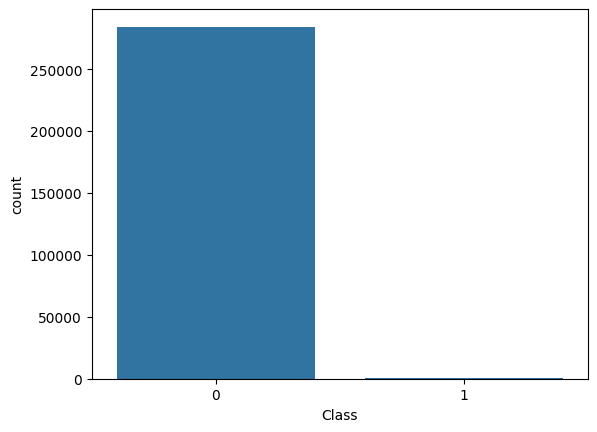

In [5]:
sns.countplot(x='Class',data=df)

In [6]:
normal = df[df.Class == 0].sample(frac=0.5,random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]

In [7]:
print(f"Normal: {normal.shape}")
print(f"Anomaly: {anomaly.shape}")

Normal: (142158, 30)
Anomaly: (492, 30)


In [8]:
normal_train, normal_test = train_test_split(normal,test_size = 0.2, random_state = 2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size = 0.2, random_state = 2020)
normal_train, normal_validate = train_test_split(normal_train,test_size = 0.25, random_state = 2020)
anomaly_train, anomaly_validate = train_test_split(anomaly_train, test_size = 0.25, random_state = 2020)

In [9]:
x_train = pd.concat((normal_train, anomaly_train))
x_test = pd.concat((normal_test, anomaly_test))
x_validate = pd.concat((normal_validate, anomaly_validate))

In [10]:
y_train = np.array(x_train["Class"])
y_test = np.array(x_test["Class"])
y_validate = np.array(x_validate["Class"])

In [11]:
x_train = x_train.drop("Class", axis=1)
x_test = x_test.drop("Class", axis=1)
x_validate = x_validate.drop("Class", axis=1)

In [12]:
print("Training sets:\nx_train: {} \ny_train:{}".format(x_train.shape, y_train.shape))
print("\nTesting sets:\nx_test: {} \ny_test:{}".format(x_test.shape, y_test.shape))
print("\nValidation sets:\nx_validate: {} \ny_validate: {}".format(x_validate.shape, y_validate.shape))

Training sets:
x_train: (85588, 29) 
y_train:(85588,)

Testing sets:
x_test: (28531, 29) 
y_test:(28531,)

Validation sets:
x_validate: (28531, 29) 
y_validate: (28531,)


In [13]:
scaler = StandardScaler()
scaler.fit(pd.concat((normal, anomaly)).drop("Class", axis=1))

,copy,True
,with_mean,True
,with_std,True


In [14]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_validate = scaler.transform(x_validate)

In [15]:
def train(sk_model, x_train, y_train):
    sk_model = sk_model.fit(x_train, y_train)
    train_acc = sk_model.score(x_train, y_train)
    mlflow.log_metric("train_acc", train_acc)
    print(f"Train Accuracy: {train_acc:.3%}")

In [22]:
def evaluate(sk_model, x_test, y_test):
    eval_acc = sk_model.score(x_test, y_test)
    preds = sk_model.predict(x_test)
    auc_score = roc_auc_score(y_test, preds)
    mlflow.log_metric("eval_acc", eval_acc) 
    mlflow.log_metric("auc_score", auc_score)
    print(f"Auc Score: {auc_score:.3%}")
    print(f"Eval Accuracy: {eval_acc:.3%}")
    roc_plot = RocCurveDisplay.from_estimator(sk_model, x_test, y_test, name='Scikit-learn ROC Curve')
    plt.savefig("sklearn_roc_plot.png")
    plt.show()
    plt.clf() 
    conf_matrix = confusion_matrix(y_test, preds)
    ax = sns.heatmap(conf_matrix, annot=True, fmt='g')
    ax.invert_xaxis()
    ax.invert_yaxis()
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title("Confusion Matrix")
    plt.savefig("sklearn_conf_matrix.png")
    
    mlflow.log_artifact("sklearn_roc_plot.png")
    mlflow.log_artifact("sklearn_conf_matrix.png")

In [17]:
#to configure your DataBricks CLI
token = dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiToken().get()
dbutils.fs.put("file:///root/.databrickscfg","[DEFAULT]\nhost=https://community.cloud.databricks.com\ntoken ="+token,overwrite=True)

NameError: name 'dbutils' is not defined

Train Accuracy: 99.894%
Auc Score: 85.341%
Eval Accuracy: 99.874%


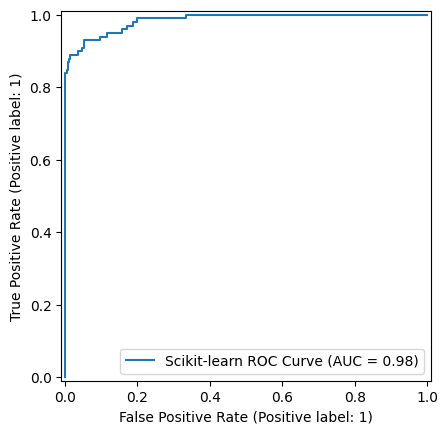

2025/11/16 14:17:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 14:18:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/16 14:18:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model run:  2d47a30db84640f9a2cf2bd4bf656561


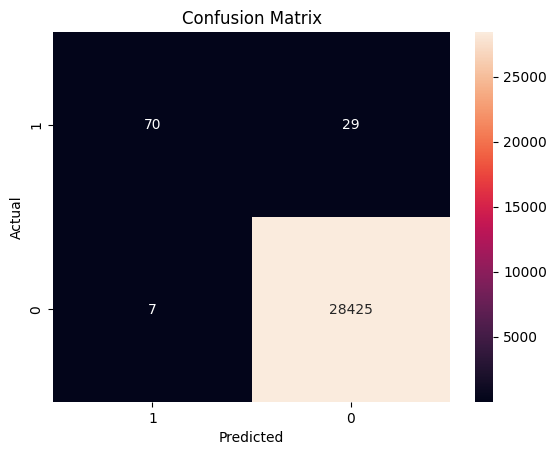

In [ ]:
sk_model = LogisticRegression(random_state=None,max_iter=10, solver='newton-cg')
mlflow.set_experiment("Databricks_Local_Lab")
with mlflow.start_run():
    train(sk_model, x_train, y_train)
    evaluate(sk_model, x_test, y_test)
    mlflow.sklearn.log_model(sk_model, "log_reg_model")
    print("Model run: ", mlflow.active_run().info.run_id)
mlflow.end_run()

/Users/alfarouq/Library/CloudStorage/OneDrive-UniversitéMohammedVIPolytechnique/S9/cloud computing/lab2/Lab Folder MLOps/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
310 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
42 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/alfarouq/Library/CloudStorage/OneDrive-UniversitéMohammedVIPolytechnique/S9/cloud computing/lab2/Lab Folder MLOps/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/alfarouq/Library/

Train Accuracy: 99.893%
Auc Score: 85.341%
Eval Accuracy: 99.874%


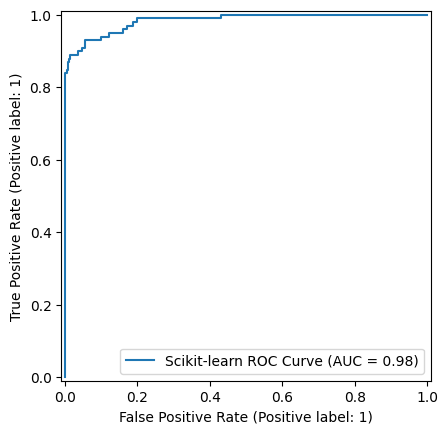

2025/11/16 14:29:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 14:29:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/16 14:29:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model run:  1651b9232f334401a35040c1aee97104


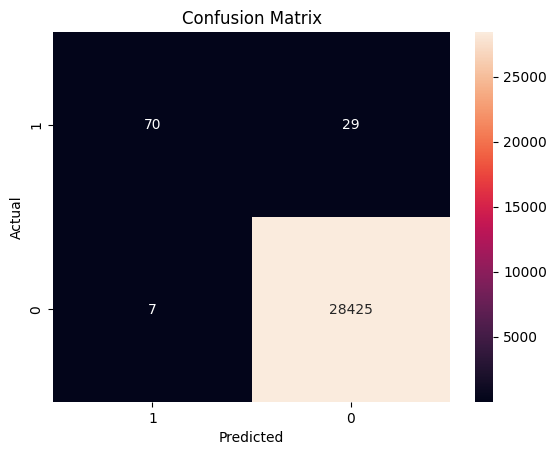

In [29]:

# define evaluation

# define search space
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
# summarize result
#print('Best Score: %s' % result.best_score_)
#print('Best Hyperparameters: %s' % result.best_params_)

model = LogisticRegression()
cv = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
space = dict()
space['solver'] = ['newton-cg', 'lbfgs', 'liblinear']
space['penalty'] = ['none', 'l1', 'l2', 'elasticnet']
space['C'] = loguniform(1e-5, 100)
mlflow.set_experiment("Databricks_Local_Lab")
with mlflow.start_run(run_name = "Logistic Regression"):
    search = RandomizedSearchCV(model, space, n_iter=50, scoring='accuracy', n_jobs=-1, cv=cv, random_state=1)
    sk_model = search.fit(x_train, y_train)
    train(sk_model, x_train, y_train)
    evaluate(sk_model, x_test, y_test)
    mlflow.sklearn.log_model(sk_model, "log_reg_model")
    print("Model run: ", mlflow.active_run().info.run_id)
mlflow.end_run()

In [33]:
all_runs = mlflow.search_runs(max_results=10)  # Note : This is pandas dataframe
display(all_runs)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_acc,metrics.eval_acc,metrics.auc_score,params.model_type,params.n_estimators,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.user
0,aafba24579d348a48e38884e630c35a2,344317408414633190,FINISHED,file:///Users/alfarouq/Library/CloudStorage/On...,2025-11-16 13:55:54.394000+00:00,2025-11-16 13:56:41.738000+00:00,0.999988,0.999019,0.888783,RandomForestClassifier,100,LOCAL,/Users/alfarouq/Library/CloudStorage/OneDrive-...,RandomForest_Model,alfarouq
1,1651b9232f334401a35040c1aee97104,344317408414633190,FINISHED,file:///Users/alfarouq/Library/CloudStorage/On...,2025-11-16 13:28:51.737000+00:00,2025-11-16 13:29:35.766000+00:00,0.998925,0.998738,0.853412,None,None,LOCAL,/Users/alfarouq/Library/CloudStorage/OneDrive-...,Logistic Regression,alfarouq
2,2d47a30db84640f9a2cf2bd4bf656561,344317408414633190,FINISHED,file:///Users/alfarouq/Library/CloudStorage/On...,2025-11-16 13:17:58.062000+00:00,2025-11-16 13:18:01.172000+00:00,0.998937,0.998738,0.853412,None,None,LOCAL,/Users/alfarouq/Library/CloudStorage/OneDrive-...,invincible-dog-461,alfarouq


TAF: 

1. réexécutez la cellule 18 en utilisant d'autres modèle ML de SKlearn 
2. comparez vos résultats en utilisant l'outil de comparaison de MLFlow

Train Accuracy: 99.999%
Auc Score: 88.878%
Eval Accuracy: 99.902%


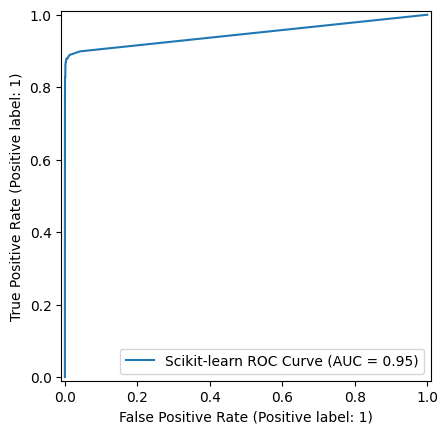

2025/11/16 14:56:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 14:56:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/11/16 14:56:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model run:  aafba24579d348a48e38884e630c35a2


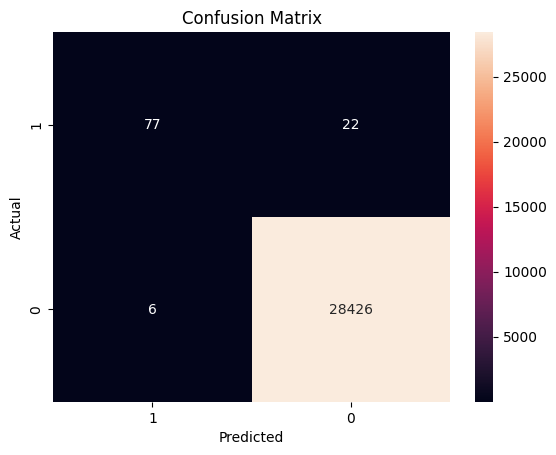

In [32]:
from sklearn.ensemble import RandomForestClassifier

mlflow.set_experiment("Databricks_Local_Lab") # Log to the same experiment

with mlflow.start_run(run_name="RandomForest_Model"):
    # Define and log parameters
    n_estimators = 100
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", n_estimators)

    # Create and train the model
    rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    train(rf_model, x_train, y_train) # Uses the helper function

    # Evaluate and log metrics
    evaluate(rf_model, x_test, y_test) # Uses the helper function

    # Log the model
    mlflow.sklearn.log_model(rf_model, "random_forest_model")

    print("Model run: ", mlflow.active_run().info.run_id)

mlflow.end_run()